<a href="https://colab.research.google.com/github/tamara-kostova/MSc_Thesis_Neuroimaging/blob/master/18_Multimodal_benchmark_layer_fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extended Multimodal Transformer Benchmark for Neuroimaging

This notebook benchmarks advanced approaches for neuroimaging classification:
- **CLIP with Layer-wise Feature Extraction**: Testing shallow/middle/deep layers
- **BiomedCLIP with Optimal Layer Selection**: Medical domain-specific features
- **Multi-Layer Fusion**: Combining features from different ViT layers

Based on recent research:
- Chen et al. (2025): MLLMs see better with shallower layers
- Niu et al. (2025): Knowledge-augmented clinical reasoning

## Installation

In [1]:
!pip install -q open_clip_torch ftfy regex
!pip install -q torch torchvision
!pip install -q scikit-learn pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00


## Imports

In [2]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from PIL import Image
import open_clip

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cpu
CUDA available: False


## Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Configuration

In [4]:
class Config:
    """Configuration for extended benchmarking"""

    BASE_DIR = "/content/drive/MyDrive/MSc_Thesis_Neuroimaging"
    DATA_DIR = os.path.join(BASE_DIR, "data/split")
    RESULTS_DIR = os.path.join(BASE_DIR, "results/layer_fusion_benchmark")

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    BATCH_SIZE = 32
    NUM_WORKERS = 2
    IMAGE_SIZE = 224
    NUM_EPOCHS = 20
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-5

    # Layer selection (based on Chen et al. 2025)
    SHALLOW_LAYER = 3   # Layers 1-12: fine-grained features
    MIDDLE_LAYER = 18   # Layers 13-20: intermediate features
    DEEP_LAYER = 23     # Layers 21-24: semantic features (penultimate)

    # Datasets
    DATASETS = {
        "MRI_tumor_binary_norm": {
            "path": os.path.join(DATA_DIR, "MRI_tumor_binary_norm"),
            "classes": ["normal", "tumor"],
        },
        "MRI_tumor_multiclass_norm": {
            "path": os.path.join(DATA_DIR, "MRI_tumor_multiclass_norm"),
            "classes": ["Carcinoma", "Germinoma", "Glioma", "Granuloma",
                       "Meduloblastoma", "Meningioma", "Neurocitoma", "Normal",
                       "Other", "Papiloma", "Schwannoma", "Tuberculoma"],
        },
        "MRI_ms_norm": {
            "path": os.path.join(DATA_DIR, "MRI_ms_norm"),
            "classes": ["Control", "MS"],
        },
        "CT_stroke_binary_norm": {
            "path": os.path.join(DATA_DIR, "CT_stroke_binary_norm"),
            "classes": ["normal", "stroke"],
        }
    }

# Create output directory
config = Config()
os.makedirs(config.RESULTS_DIR, exist_ok=True)

print(f"Using device: {config.DEVICE}")
print(f"Results will be saved to: {config.RESULTS_DIR}")

Using device: cpu
Results will be saved to: /content/drive/MyDrive/MSc_Thesis_Neuroimaging/results/layer_fusion_benchmark


## Dataset Class

In [15]:
class NeuroimagingDataset(Dataset):
    """Dataset for neuroimaging classification"""

    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.transform = transform

        self.images = []
        self.labels = []

        split_dir = self.root_dir / split
        if not split_dir.exists():
            raise ValueError(f"Split directory {split_dir} does not exist")

        # Get class directories
        class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
        self.class_names = [d.name for d in class_dirs]
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}

        # Load images
        for class_dir in class_dirs:
            class_idx = self.class_to_idx[class_dir.name]
            for ext in ['*.png', '*.jpg', '*.jpeg']:
                for img_path in class_dir.glob(ext):
                    self.images.append(str(img_path))
                    self.labels.append(class_idx)

        print(f"Loaded {len(self.images)} images from {split} split")
        print(f"Classes: {self.class_names}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

## Model: CLIP with Layer Selection

This model extracts features from a specific ViT layer and trains a classifier.

In [6]:
class CLIPLayerClassifier(nn.Module):
    """CLIP with specific layer feature extraction"""

    def __init__(self, num_classes, model_name='ViT-L-14', pretrained='openai', layer_idx=23):
        super().__init__()

        # Load CLIP
        self.model, _, _ = open_clip.create_model_and_transforms(
            model_name, pretrained=pretrained
        )
        self.model.eval()

        # Freeze CLIP
        for param in self.model.parameters():
            param.requires_grad = False

        self.layer_idx = layer_idx
        self.feature_dim = 1024 if 'L' in model_name else 768  # ViT-L vs ViT-B

        # Classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_dim),
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def extract_layer_features(self, images):
        """Extract features from specific CLIP layer"""
        with torch.no_grad():
            # Forward through vision encoder
            x = self.model.visual.conv1(images)
            x = x.reshape(x.shape[0], x.shape[1], -1)
            x = x.permute(0, 2, 1)

            # Add class token and position embedding
            x = torch.cat([
                self.model.visual.class_embedding.to(x.dtype) +
                torch.zeros(x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device),
                x
            ], dim=1)
            x = x + self.model.visual.positional_embedding.to(x.dtype)
            x = self.model.visual.ln_pre(x)

            # Extract from specific layer
            for i, block in enumerate(self.model.visual.transformer.resblocks):
                x = block(x)
                if i == self.layer_idx:
                    # Take CLS token
                    features = x[:, 0, :]
                    break

        return features

    def forward(self, images):
        features = self.extract_layer_features(images)
        logits = self.classifier(features)
        return logits

## Model: Multi-Layer Fusion

Combines features from shallow, middle, and deep layers.

In [7]:
class CLIPMultiLayerFusion(nn.Module):
    """CLIP with multi-layer feature fusion"""

    def __init__(self, num_classes, model_name='ViT-L-14', pretrained='openai',
                 layers=[3, 18, 23], fusion='concat'):
        super().__init__()

        # Load CLIP
        self.model, _, _ = open_clip.create_model_and_transforms(
            model_name, pretrained=pretrained
        )
        self.model.eval()

        # Freeze CLIP
        for param in self.model.parameters():
            param.requires_grad = False

        self.layers = layers
        self.fusion = fusion
        self.feature_dim = 1024 if 'L' in model_name else 768

        # Fusion
        if fusion == 'concat':
            fusion_dim = self.feature_dim * len(layers)
        elif fusion == 'weighted':
            fusion_dim = self.feature_dim
            self.layer_weights = nn.Parameter(torch.ones(len(layers)) / len(layers))
        else:
            raise ValueError(f"Unknown fusion: {fusion}")

        # Classifier
        self.classifier = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def extract_multi_layer_features(self, images):
        """Extract features from multiple layers"""
        features = []

        with torch.no_grad():
            x = self.model.visual.conv1(images)
            x = x.reshape(x.shape[0], x.shape[1], -1)
            x = x.permute(0, 2, 1)
            x = torch.cat([
                self.model.visual.class_embedding.to(x.dtype) +
                torch.zeros(x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device),
                x
            ], dim=1)
            x = x + self.model.visual.positional_embedding.to(x.dtype)
            x = self.model.visual.ln_pre(x)

            # Extract from multiple layers
            for i, block in enumerate(self.model.visual.transformer.resblocks):
                x = block(x)
                if i in self.layers:
                    features.append(x[:, 0, :].clone())

        return features

    def forward(self, images):
        layer_features = self.extract_multi_layer_features(images)

        # Fuse
        if self.fusion == 'concat':
            fused = torch.cat(layer_features, dim=1)
        elif self.fusion == 'weighted':
            weights = F.softmax(self.layer_weights, dim=0)
            fused = sum(w * f for w, f in zip(weights, layer_features))

        logits = self.classifier(fused)
        return logits

## Training and Evaluation

In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': total_loss / (pbar.n + 1), 'acc': 100. * correct / total})

    return total_loss / len(dataloader), correct / total

def evaluate(model, dataloader, device):
    """Evaluate model"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)

    if all_probs.shape[1] == 2:
        precision = precision_score(all_labels, all_preds, zero_division=0)
        recall = recall_score(all_labels, all_preds, zero_division=0)
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        try:
            auc = roc_auc_score(all_labels, all_probs[:, 1])
        except:
            auc = 0.0
    else:
        precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
        try:
            auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
        except:
            auc = 0.0

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

## Run Benchmark

Test different layer configurations and fusion strategies.

In [9]:
def run_benchmark_for_dataset(dataset_name, dataset_config, config):
    """Run benchmark for a single dataset"""

    print(f"\n{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*70}\n")

    # Prepare data
    transform = transforms.Compose([
        transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = NeuroimagingDataset(dataset_config['path'], 'train', transform)
    test_dataset = NeuroimagingDataset(dataset_config['path'], 'test', transform)

    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE,
                             shuffle=True, num_workers=config.NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE,
                            shuffle=False, num_workers=config.NUM_WORKERS)

    num_classes = len(dataset_config['classes'])
    results = []

    # Model configurations
    model_configs = [
        {'name': f'CLIP-Layer{config.SHALLOW_LAYER}', 'type': 'single', 'layer': config.SHALLOW_LAYER},
        {'name': f'CLIP-Layer{config.MIDDLE_LAYER}', 'type': 'single', 'layer': config.MIDDLE_LAYER},
        {'name': f'CLIP-Layer{config.DEEP_LAYER}', 'type': 'single', 'layer': config.DEEP_LAYER},
        {'name': 'CLIP-Fusion-Concat', 'type': 'fusion', 'fusion': 'concat'},
        {'name': 'CLIP-Fusion-Weighted', 'type': 'fusion', 'fusion': 'weighted'},
    ]

    for model_config in model_configs:
        print(f"\n{'='*70}")
        print(f"Training: {model_config['name']}")
        print(f"{'='*70}\n")

        # Create model
        if model_config['type'] == 'single':
            model = CLIPLayerClassifier(num_classes, layer_idx=model_config['layer'])
        else:
            model = CLIPMultiLayerFusion(
                num_classes,
                layers=[config.SHALLOW_LAYER, config.MIDDLE_LAYER, config.DEEP_LAYER],
                fusion=model_config['fusion']
            )

        model = model.to(config.DEVICE)

        # Setup training
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY
        )

        # Train
        best_acc = 0
        patience = 5
        patience_counter = 0

        for epoch in range(config.NUM_EPOCHS):
            print(f"\nEpoch {epoch+1}/{config.NUM_EPOCHS}")
            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
            metrics = evaluate(model, test_loader, config.DEVICE)

            print(f"Test: Acc={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}")

            if metrics['accuracy'] > best_acc:
                best_acc = metrics['accuracy']
                best_metrics = metrics.copy()
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        # Save results
        result = {
            'dataset': dataset_name,
            'model': model_config['name'],
            **best_metrics
        }
        results.append(result)
        print(f"\nBest results: {result}")

    return results

In [16]:
# Run benchmarks
all_results = []

for dataset_name, dataset_config in config.DATASETS.items():
    try:
        results = run_benchmark_for_dataset(dataset_name, dataset_config, config)
        all_results.extend(results)
    except Exception as e:
        print(f"Error with {dataset_name}: {e}")
        import traceback
        traceback.print_exc()
        continue

# Save results
results_df = pd.DataFrame(all_results)
results_file = os.path.join(config.RESULTS_DIR, 'layer_fusion_results.csv')
results_df.to_csv(results_file, index=False)

print(f"\n{'='*70}")
print("FINAL RESULTS")
print(f"{'='*70}\n")
print(results_df.to_string())
print(f"\nResults saved to: {results_file}")


Dataset: MRI_tumor_binary_norm

Loaded 2100 images from train split
Classes: ['normal', 'tumor']
Loaded 450 images from test split
Classes: ['normal', 'tumor']

Training: CLIP-Layer3


Epoch 1/20


Evaluating: 100%|██████████| 15/15 [04:34<00:00, 18.33s/it]


Test: Acc=0.7556, F1=0.7609, AUC=0.8470

Epoch 2/20


Evaluating: 100%|██████████| 15/15 [04:16<00:00, 17.10s/it]


Test: Acc=0.7956, F1=0.7880, AUC=0.8991

Epoch 3/20


...

Test: Acc=0.8933, F1=0.8829, AUC=0.9834

Epoch 20/20


Evaluating: 100%|██████████| 15/15 [04:20<00:00, 17.34s/it]


Test: Acc=0.9244, F1=0.9217, AUC=0.9833

Best results: {'dataset': 'MRI_tumor_binary_norm', 'model': 'CLIP-Layer3', 'accuracy': 0.9422222222222222, 'precision': 0.9502262443438914, 'recall': 0.9333333333333333, 'f1': 0.9417040358744395, 'auc': np.float64(0.9816493827160495)}

Training: CLIP-Layer18


Epoch 1/20


Training:  35%|███▍      | 23/66 [35:17<1:05:59, 92.07s/it, loss=0.462, acc=77.4]


KeyboardInterrupt: 

## Visualization

KeyError: 'dataset'

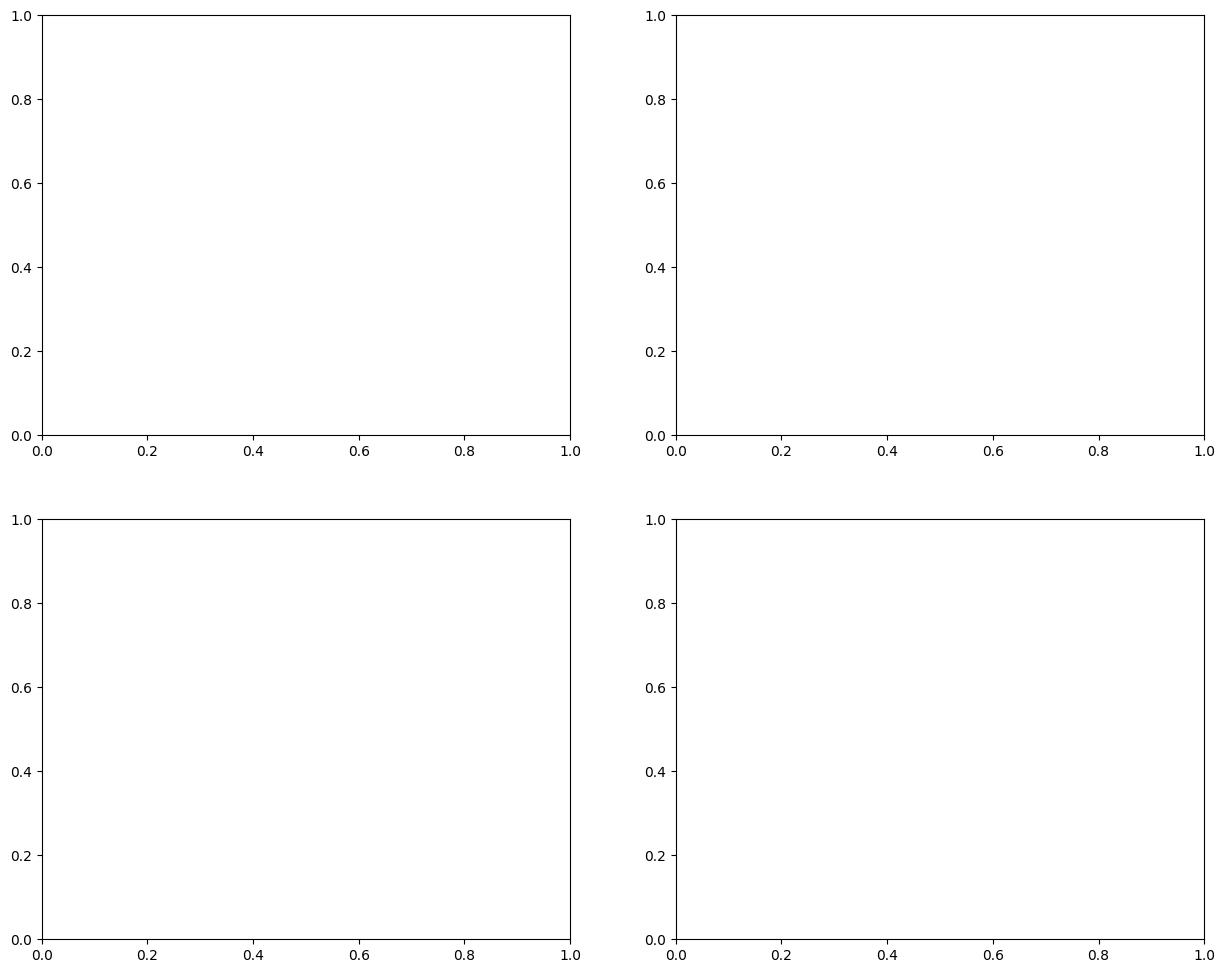

In [20]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

metrics_to_plot = ['accuracy', 'f1', 'precision', 'recall']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]

    pivot = results_df.pivot(index='dataset', columns='model', values=metric)
    pivot.plot(kind='bar', ax=ax, rot=45)

    ax.set_title(f'{metric.capitalize()} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlabel('Dataset', fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_file = os.path.join(config.RESULTS_DIR, 'layer_fusion_comparison.png')
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {plot_file}")

## Summary Statistics

In [21]:
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70 + "\n")

# Average by model
print("Average Performance by Model:")
avg_by_model = results_df.groupby('model')[['accuracy', 'f1', 'auc']].mean()
print(avg_by_model.to_string())

# Best model per dataset
print("\n\nBest Model per Dataset (by Accuracy):")
best_per_dataset = results_df.loc[results_df.groupby('dataset')['accuracy'].idxmax()]
print(best_per_dataset[['dataset', 'model', 'accuracy', 'f1']].to_string(index=False))

# Layer comparison
print("\n\nSingle Layer Performance:")
layer_results = results_df[results_df['model'].str.contains('Layer')]
if not layer_results.empty:
    print(layer_results.groupby('model')[['accuracy', 'f1']].mean().to_string())


SUMMARY STATISTICS

Average Performance by Model:


KeyError: 'model'